In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from pathlib import Path

%matplotlib inline
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['font.family'] = 'sans-serif'

sys.path.append(str(Path.cwd()))
from data_pipeline import EDA, DataPipeline

# Phần 2 — Ứng Dụng Data Fitting vào Dữ Liệu Thực Tế

## I. Giới thiệu bộ dữ liệu

Dữ liệu được trích xuất từ **NHANES** (National Health and Nutrition Examination Survey) chu kỳ 2021–2023, công bố bởi CDC Hoa Kỳ:  
[CDC NHANES 2021-2023](https://wwwn.cdc.gov/nchs/nhanes/search/datapage.aspx?Component=Questionnaire&Cycle=2021-2023)

Mục tiêu: dự đoán huyết áp tâm thu trung bình (`SYSTOLIC_TARGET`) từ các chỉ số y sinh học và lối sống. Bộ dữ liệu thô được ghép từ 10 file SAS Transport (`.xpt`) của các bảng thành phần (Demographics, Body Measures, Blood Pressure, Laboratory Tests,...) theo mã định danh `SEQN` của mỗi đáp viên, sử dụng script `merge_nhanes.py`.

In [3]:
df_raw = pd.read_csv('data/processed/nhanes_stroke_raw.csv')
print(f"Bộ dữ liệu thô sau merge: {df_raw.shape[0]:,} dòng × {df_raw.shape[1]} cột")
print(f"\nCác cột: {list(df_raw.columns)}")
df_raw.head()

Bộ dữ liệu thô sau merge: 11,933 dòng × 21 cột

Các cột: ['SEQN', 'RIDAGEYR', 'RIAGENDR', 'BMXHT', 'BMXWT', 'BMXBMI', 'BMXWAIST', 'BPXOSY1', 'BPXOSY2', 'BPXOSY3', 'BPXOPLS1', 'BPXOPLS2', 'BPXOPLS3', 'SMQ020', 'DIQ010', 'MCQ160E', 'MCQ160F', 'PAQ680', 'SLD012', 'LBXTC', 'LBXSCR']


,SEQN,RIDAGEYR,RIAGENDR,BMXHT,BMXWT,BMXBMI,BMXWAIST,BPXOSY1,BPXOSY2,BPXOSY3,...,BPXOPLS2,BPXOPLS3,SMQ020,DIQ010,MCQ160E,MCQ160F,PAQ680,SLD012,LBXTC,LBXSCR
0,130378.0,43.0,1.0,179.5,86.9,27.0,98.3,135.0,131.0,132.0,...,79.0,82.0,1.0,2.0,2.0,2.0,360.0,9.5,264.0,0.80
1,130379.0,66.0,1.0,174.2,101.8,33.5,114.7,121.0,117.0,113.0,...,71.0,73.0,1.0,2.0,2.0,2.0,480.0,9.0,214.0,0.79
2,130380.0,44.0,2.0,152.9,69.4,29.7,93.5,111.0,112.0,104.0,...,83.0,77.0,2.0,1.0,2.0,2.0,240.0,8.0,187.0,0.64
3,130381.0,5.0,2.0,120.1,34.3,23.8,70.4,NaN,NaN,NaN,...,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN
4,130382.0,2.0,1.0,NaN,13.6,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN


### Bảng ánh xạ ý nghĩa các biến đặc trưng (21 cột thô)

Để hỗ trợ tra cứu nhanh nguồn gốc và ý nghĩa y khoa của các cột dữ liệu trước khi thực hiện EDA, bảng dưới đây liệt kê chi tiết mô tả biến được tham chiếu trực tiếp từ danh mục biến CDC NHANES:

| Mã biến (Variable) | Tên tiếng Anh đầy đủ (CDC Definition) | Ý nghĩa y khoa / Mô tả tiếng Việt | Nguồn bảng dữ liệu |
| :--- | :--- | :--- | :--- |
| `SEQN` | Respondent sequence number | Mã định danh người tham gia khảo sát | DEMO_L (Demographics) |
| `RIDAGEYR` | Age in years at screening | Tuổi của người tham gia khảo sát (năm) | DEMO_L (Demographics) |
| `RIAGENDR` | Gender | Giới tính (1: Nam, 2: Nữ) | DEMO_L (Demographics) |
| `BMXHT` | Standing height (cm) | Chiều cao đứng khi đo nhân trắc học | BMX_L (Body Measures) |
| `BMXWT` | Weight (kg) | Cân nặng của người tham gia | BMX_L (Body Measures) |
| `BMXBMI` | Body Mass Index (kg/m²) | Chỉ số khối cơ thể | BMX_L (Body Measures) |
| `BMXWAIST` | Waist circumference (cm) | Chu vi vòng eo | BMX_L (Body Measures) |
| `BPXOSY1` | Oscillometric Systolic BP - 1st reading | Huyết áp tâm thu đo máy tự động - Lần 1 (mmHg) | BPXO_L (Blood Pressure) |
| `BPXOSY2` | Oscillometric Systolic BP - 2nd reading | Huyết áp tâm thu đo máy tự động - Lần 2 (mmHg) | BPXO_L (Blood Pressure) |
| `BPXOSY3` | Oscillometric Systolic BP - 3rd reading | Huyết áp tâm thu đo máy tự động - Lần 3 (mmHg) | BPXO_L (Blood Pressure) |
| `BPXOPLS1` | Oscillometric Pulse - 1st reading | Nhịp tim đo máy tự động - Lần 1 (nhịp/phút) | BPXO_L (Blood Pressure) |
| `BPXOPLS2` | Oscillometric Pulse - 2nd reading | Nhịp tim đo máy tự động - Lần 2 (nhịp/phút) | BPXO_L (Blood Pressure) |
| `BPXOPLS3` | Oscillometric Pulse - 3rd reading | Nhịp tim đo máy tự động - Lần 3 (nhịp/phút) | BPXO_L (Blood Pressure) |
| `SMQ020` | Smoked at least 100 cigarettes in life | Đã từng hút ≥ 100 điếu thuốc trong đời | SMQ_L (Smoking) |
| `DIQ010` | Doctor told you have diabetes | Từng được bác sĩ chẩn đoán bị tiểu đường | DIQ_L (Diabetes) |
| `MCQ160E` | Ever told you had coronary heart disease | Từng được chẩn đoán mắc bệnh mạch vành | MCQ_L (Medical Conditions) |
| `MCQ160F` | Ever told you had a stroke | Từng được chẩn đoán bị đột quỵ | MCQ_L (Medical Conditions) |
| `PAQ680` | Minutes sedentary activity per day | Số phút hoạt động tĩnh tại/ngồi một chỗ mỗi ngày | PAQ_L (Physical Activity) |
| `SLD012` | Number of hours of sleep on weekdays | Số giờ ngủ trung bình mỗi đêm trong tuần | SLQ_L (Sleep Disorders) |
| `LBXTC` | Total Cholesterol (mg/dL) | Tổng lượng Cholesterol trong huyết thanh | TCHOL_L (Total Cholesterol) |
| `LBXSCR` | Blood/Serum Creatinine (mg/dL) | Nồng độ Creatinine trong huyết thanh (chức năng thận) | BIOPRO_L (Biochemistry Profile) |


---
## II. EDA Lần 1 — Khảo sát dữ liệu thô

Phân tích khám phá ban đầu nhằm đánh giá tỷ lệ khuyết thiếu, tương quan với biến mục tiêu, và hiện tượng đa cộng tuyến — từ đó quyết định giữ lại biến nào cho mô hình.

In [4]:
eda_raw = EDA(df_raw.copy())
missing = eda_raw.missingRate()

df_missing = pd.DataFrame({
    'Cột': df_raw.columns,
    'Tỷ lệ khuyết (%)': [round(r * 100, 2) for r in missing]
}).sort_values('Tỷ lệ khuyết (%)', ascending=False).reset_index(drop=True)

print("Tỷ lệ dữ liệu khuyết theo từng cột:")
df_missing

Tỷ lệ dữ liệu khuyết theo từng cột:


,Cột,Tỷ lệ khuyết (%)
0,LBXSCR,46.99
1,LBXTC,42.26
2,BPXOPLS3,37.32
3,BPXOSY3,37.32
4,BPXOSY2,37.11
5,BPXOPLS2,37.11
6,BPXOSY1,37.01
7,BPXOPLS1,37.01
8,MCQ160F,34.58
9,MCQ160E,34.58


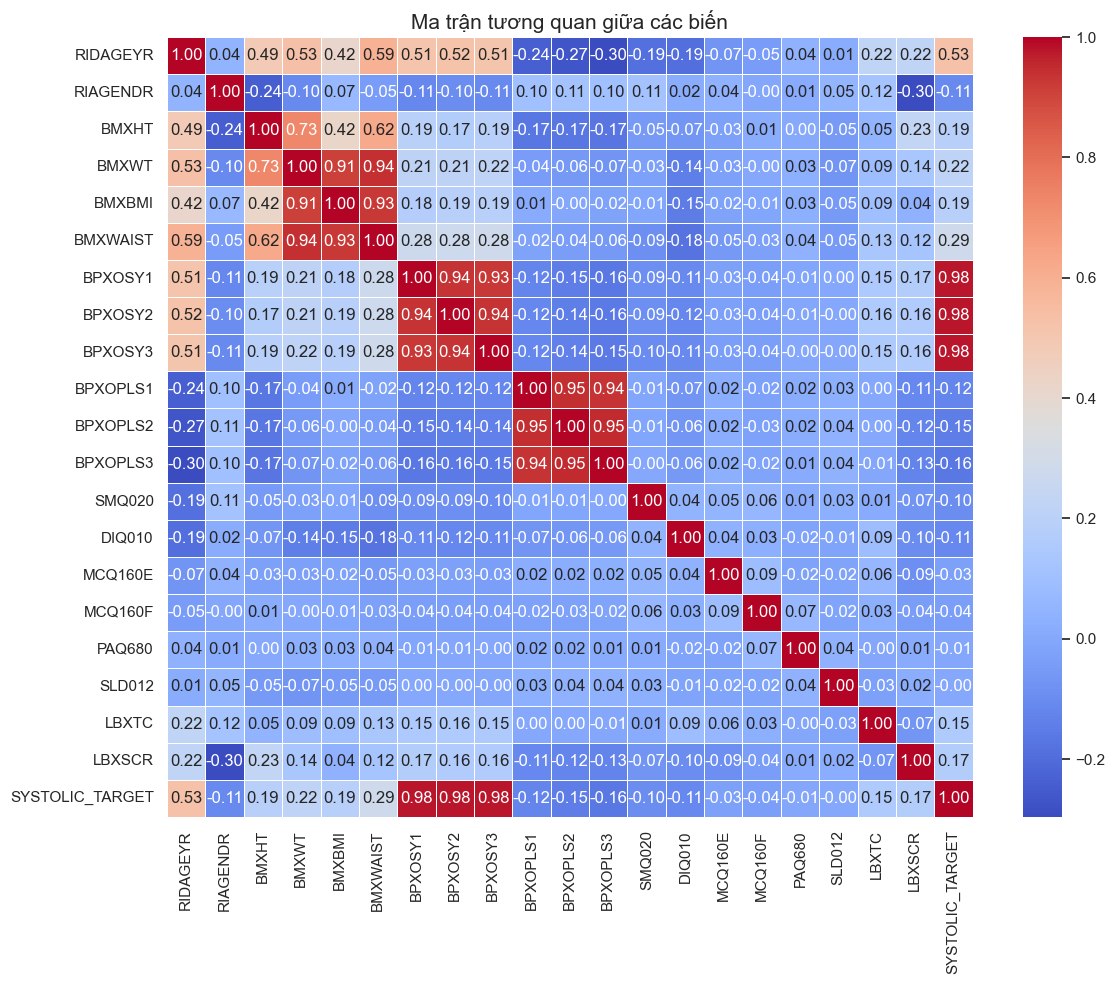

In [5]:
df_corr = df_raw.drop(columns=['SEQN']).copy()
df_corr['SYSTOLIC_TARGET'] = df_corr[['BPXOSY1','BPXOSY2','BPXOSY3']].mean(axis=1)

eda_corr = EDA(df_corr)
eda_corr.plot_correlation_heatmap()

### Kết luận EDA Lần 1

Từ bảng tỷ lệ khuyết và ma trận tương quan:

1. **Tương quan thấp** với huyết áp: `SLD012` (thời gian ngủ), `PAQ680` (thời gian ngồi), `MCQ160E` (đau thắt ngực), `MCQ160F` (đột quỵ) gần như không đóng góp giá trị dự đoán → loại bỏ.
2. **Đa cộng tuyến**: `BMXHT` (chiều cao), `BMXWT` (cân nặng), `BMXWAIST` (chu vi eo) tương quan mạnh với `BMXBMI`. Chỉ giữ `BMXBMI` làm đại diện để tránh đa cộng tuyến.
3. Lọc dòng thiếu hoàn toàn cả 3 lần đo huyết áp tâm thu.
4. Lọc outlier ngoài giới hạn sinh lý (huyết áp ngoài 40–260 mmHg, BMI ngoài 10–90,...).
5. Gộp 3 lần đo huyết áp → `SYSTOLIC_TARGET`, 3 lần đo nhịp tim → `BPXOPLS`.

Quá trình tinh lọc được thực hiện bởi `prep_checkpoint.py`, thu gọn bộ dữ liệu xuống còn **10 cột** và khoảng **7,500 dòng**.

---
## III. Dữ liệu sau tiền xử lý

Quá trình tinh lọc trong `prep_checkpoint.py` gồm 8 bước: load dữ liệu thô → chọn 14 cột mục tiêu → lọc dòng không có đo huyết áp → lọc outlier sinh học → lưu checkpoint → gộp 3 lần đo thành trung bình → báo cáo missing → xuất file cuối cùng.

In [6]:
df_pre = pd.read_csv('data/processed/nhanes_pre_pipeline.csv')
print(f"Dữ liệu sau tiền xử lý: {df_pre.shape[0]:,} dòng × {df_pre.shape[1]} cột")
print(f"\nCác cột: {list(df_pre.columns)}")
df_pre.head()

Dữ liệu sau tiền xử lý: 7,515 dòng × 10 cột

Các cột: ['SEQN', 'RIDAGEYR', 'RIAGENDR', 'BMXBMI', 'SMQ020', 'DIQ010', 'LBXTC', 'LBXSCR', 'SYSTOLIC_TARGET', 'BPXOPLS']


,SEQN,RIDAGEYR,RIAGENDR,BMXBMI,SMQ020,DIQ010,LBXTC,LBXSCR,SYSTOLIC_TARGET,BPXOPLS
0,130378.0,43.0,1.0,27.0,1.0,2.0,264.0,0.80,132.666667,81.000000
1,130379.0,66.0,1.0,33.5,1.0,2.0,214.0,0.79,117.000000,72.000000
2,130380.0,44.0,2.0,29.7,2.0,1.0,187.0,0.64,109.000000,81.333333
3,130386.0,34.0,1.0,30.2,1.0,2.0,183.0,0.82,115.000000,62.333333
4,130387.0,68.0,2.0,42.6,2.0,2.0,203.0,0.76,141.333333,79.000000


---
## IV. EDA Lần 2 — Kiểm chứng dữ liệu đã xử lý

Sau tiền xử lý, chúng tôi thực hiện EDA lần 2 trên `nhanes_pre_pipeline.csv` để xác nhận dữ liệu đã sạch và phù hợp cho mô hình. Các hàm thống kê được cài đặt thủ công trong class `EDA` (không dùng `.describe()` hay numpy).

In [7]:
eda_pre = EDA(df_pre.drop(columns=['SEQN']).copy())

means = eda_pre.meanImple()
quantiles = eda_pre.medianAndQuantilesImple()
stds = eda_pre.stdImple()
mins = eda_pre.minImple()
maxs = eda_pre.maxImple()

cols = list(eda_pre.df.columns)
stats_df = pd.DataFrame({
    'Biến': cols,
    'Mean': [round(v, 2) for v in means],
    'Std': [round(v, 2) for v in stds],
    'Min': [round(v, 2) if v is not None else None for v in mins],
    'Q1': [round(q[0], 2) if q[0] is not None else None for q in quantiles],
    'Median': [round(q[1], 2) if q[1] is not None else None for q in quantiles],
    'Q3': [round(q[2], 2) if q[2] is not None else None for q in quantiles],
    'Max': [round(v, 2) if v is not None else None for v in maxs],
})

print("Thống kê mô tả (cài đặt thủ công từ class EDA):")
stats_df

Thống kê mô tả (cài đặt thủ công từ class EDA):


,Biến,Mean,Std,Min,Q1,Median,Q3,Max
0,RIDAGEYR,45.00,22.66,8.00,23.00,47.00,65.00,80.00
1,RIAGENDR,1.54,0.50,1.00,1.00,2.00,2.00,2.00
2,BMXBMI,28.26,7.56,11.10,23.10,27.20,32.30,68.90
3,SMQ020,1.61,0.54,1.00,1.00,2.00,2.00,9.00
4,DIQ010,1.92,0.37,1.00,2.00,2.00,2.00,3.00
5,LBXTC,182.44,42.35,62.00,152.00,179.00,208.00,438.00
6,LBXSCR,0.87,0.31,0.35,0.70,0.83,0.98,8.66
7,SYSTOLIC_TARGET,119.09,18.14,70.00,106.33,116.33,129.00,232.33
8,BPXOPLS,73.04,12.57,34.00,64.33,72.33,81.00,151.00


In [8]:
missing_pre = eda_pre.missingRate()
print("Tỷ lệ khuyết theo cột:")
for col, rate in zip(cols, missing_pre):
    print(f"  {col:20s}: {rate*100:6.2f}%")

print()
eda_dup = EDA(df_pre.copy())
eda_dup.check_duplicates()

print(f"\n--- Kiểm tra outlier trên dữ liệu đã xử lý ---")
print(f"Số dòng trước: {len(eda_pre.df)}")
eda_pre.detectOutliers()
eda_pre.detectOutliersIQR()
print(f"Số dòng sau:  {len(eda_pre.df)}")

Tỷ lệ khuyết theo cột:
  RIDAGEYR            :   0.00%
  RIAGENDR            :   0.00%
  BMXBMI              :   0.86%
  SMQ020              :  18.59%
  DIQ010              :   0.00%
  LBXTC               :  12.77%
  LBXSCR              :  18.42%
  SYSTOLIC_TARGET     :   0.00%
  BPXOPLS             :   0.00%

Dòng trùng hoàn toàn: 0
ID trùng: 0

--- Kiểm tra outlier trên dữ liệu đã xử lý ---
Số dòng trước: 7515
detectOutliers: loại 0 hàng → còn 7515
detectOutliersIQR: loại 212 hàng → còn 7303
Số dòng sau:  7303


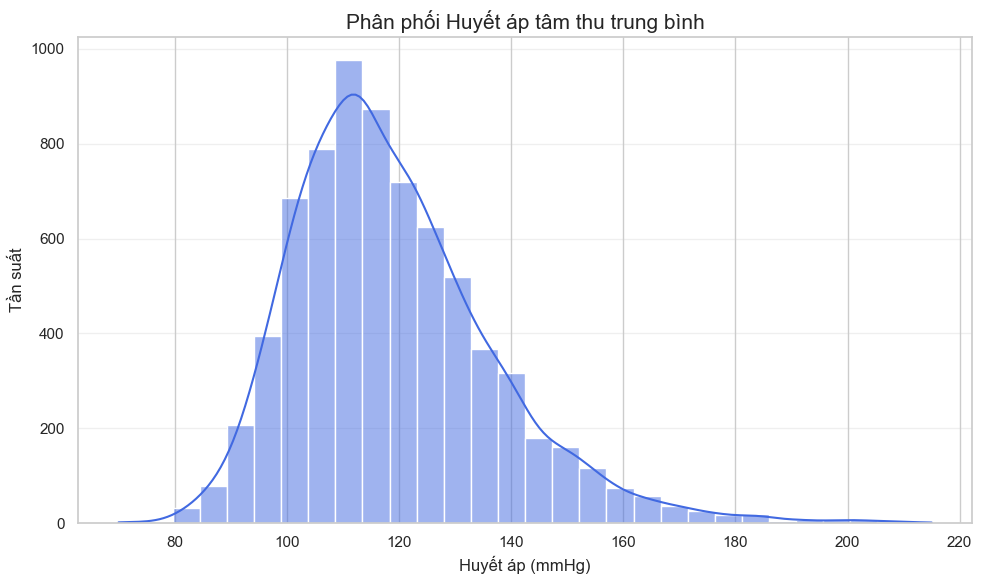

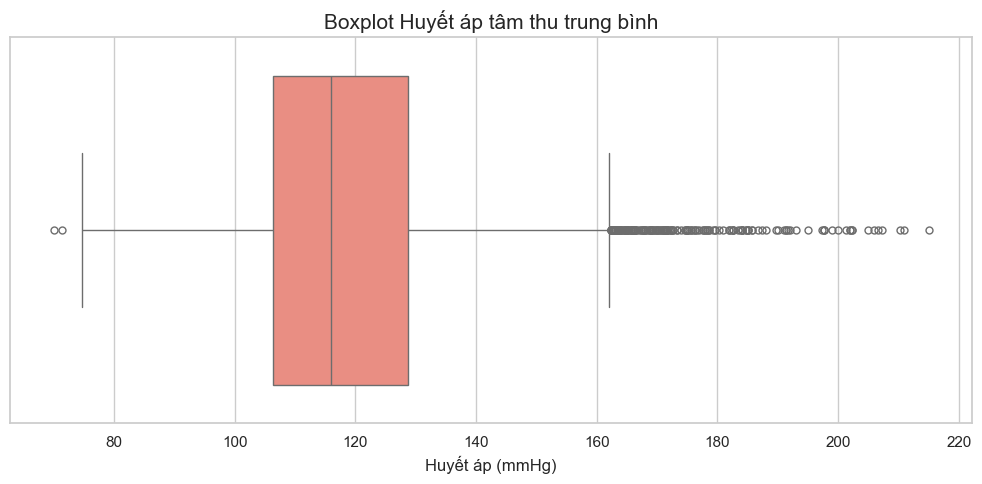

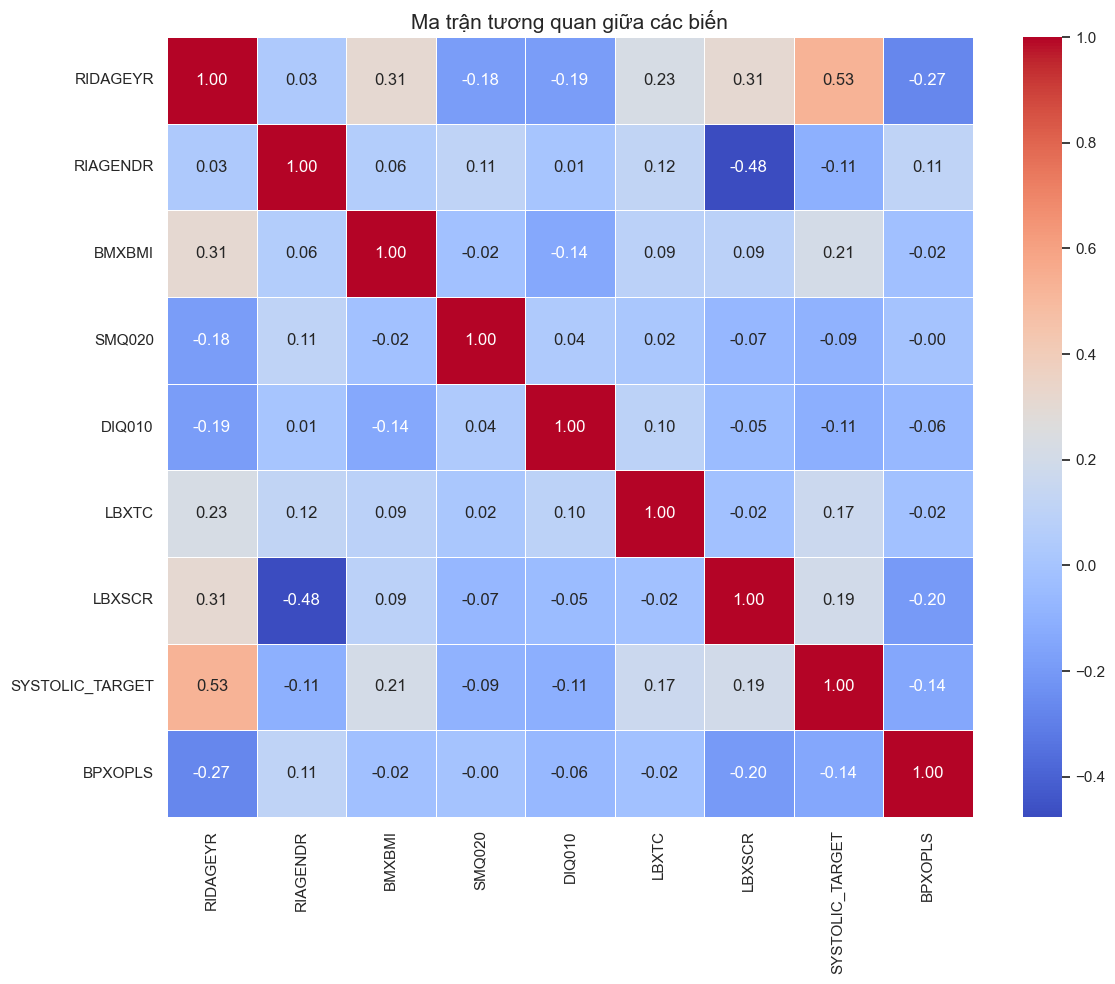

In [9]:
eda_pre.plot_target_histogram()
eda_pre.plot_target_boxplot()
eda_pre.plot_correlation_heatmap()

### Nhận xét EDA Lần 2

- Phân phối huyết áp lệch phải (right-skewed), tập trung quanh 115–130 mmHg — đặc trưng dân số trưởng thành.
- Boxplot xác nhận các giá trị huyết áp cao (170–195 mmHg) vẫn được giữ lại hợp lý — đây là bệnh nhân tăng huyết áp thực sự.
- `RIDAGEYR` (tuổi) có tương quan thuận mạnh nhất với huyết áp, tiếp theo là `BMXBMI`, `LBXSCR` và `BPXOPLS`.
- Một số cột vẫn còn missing values — sẽ được xử lý bởi `DataPipeline` (median/mode imputation theo tập train) để ngăn data leakage.

---
## V. DataPipeline — Chuẩn hóa & Chia tập dữ liệu (KNN Imputer Nâng Cao)

Class `DataPipeline` thực hiện fit/transform chuẩn: mọi tham số chuẩn hóa (mean, std, category maps) và tập nguồn (donor pool) chỉ được học và trích xuất từ tập train để ngăn chặn triệt để **data leakage**.

Quy trình xử lý nâng cao gồm các pha khép kín:
1. **Remap & Lọc nhiễu ban đầu**: Chuyển đổi các giá trị khảo sát không hợp lệ (`SMQ020` ∈ {7, 9} → NaN).
2. **Xây dựng Donor Pool sạch (from scratch)**: Trích xuất các bản ghi đầy đủ dữ liệu (complete cases) từ tập Train, sau đó áp dụng **bộ lọc ngoại lai IQR * 2.5** để loại bỏ các outliers y sinh cực đoan, bảo vệ quá trình điền khuyết khỏi các điểm nhiễu.
3. **KNN Imputation với Trọng số khoảng cách**: Sử dụng **NaN-Euclidean distance** trên các đặc trưng liên tục đã chuẩn hóa Z-score. Giá trị điền khuyết được tính bằng **trung bình có trọng số nghịch đảo khoảng cách** ($w_i = 1 / (d_i + 10^{-8})$) cho biến liên tục, và **bầu chọn có trọng số** cho biến phân loại.
4. **Encoding & Chuẩn hóa**: Thực hiện one-hot encoding (drop_first), chuẩn hóa Z-score tĩnh cho toàn bộ biến liên tục và thêm cột bias ở đầu.

In [10]:
CONTINUOUS  = ['RIDAGEYR', 'BMXBMI', 'BPXOPLS', 'LBXTC', 'LBXSCR']
CATEGORICAL = ['RIAGENDR', 'SMQ020', 'DIQ010']
INVALID     = {'SMQ020': [7.0, 9.0]}

pipe = DataPipeline(CONTINUOUS, CATEGORICAL,
                    target_col='SYSTOLIC_TARGET',
                    invalid_cat_values=INVALID)

X_tr_df, X_te_df, y_train, y_test = pipe.load_and_split(
    'data/processed/nhanes_pre_pipeline.csv', seed=42)
X_train, feat_names = pipe.fit_transform(X_tr_df)
X_test, _ = pipe.transform(X_te_df)

print(f"Train: {X_train.shape[0]} mẫu | Test: {X_test.shape[0]} mẫu")
print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")
print(f"Features: {feat_names}\n")
pipe.summary()

Donor pool sau lọc outlier sinh học/IQR: còn 4171 bản ghi sạch.
Train: 6012 mẫu | Test: 1503 mẫu
X_train: (6012, 10) | X_test: (1503, 10)
Features: ['bias', 'RIDAGEYR', 'BMXBMI', 'BPXOPLS', 'LBXTC', 'LBXSCR', 'RIAGENDR_2.0', 'SMQ020_2.0', 'DIQ010_2.0', 'DIQ010_3.0']

=== DataPipeline Summary (KNN Imputer Nâng Cao) ===
  Fitted: True
  k-Neighbors: 5
  Donor Pool Size: 4171 bản ghi sạch.
  Continuous (5): ['RIDAGEYR', 'BMXBMI', 'BPXOPLS', 'LBXTC', 'LBXSCR']
  Categorical (3): ['RIAGENDR', 'SMQ020', 'DIQ010']
  Scaler (mean / std):
    RIDAGEYR: mean=44.7996, std=22.5979
    BMXBMI: mean=28.2539, std=7.5998
    BPXOPLS: mean=73.0916, std=12.5113
    LBXTC: mean=182.1743, std=42.1414
    LBXSCR: mean=0.8687, std=0.3092
  Category maps:
    RIAGENDR: [np.float64(1.0), np.float64(2.0)]
    SMQ020: [np.float64(1.0), np.float64(2.0)]
    DIQ010: [np.float64(1.0), np.float64(2.0), np.float64(3.0)]
  Output features (10): ['bias', 'RIDAGEYR', 'BMXBMI', 'BPXOPLS', 'LBXTC', 'LBXSCR', 'RIAGENDR_2.

---
## VI. Huấn luyện & So sánh mô hình

Chúng tôi thử nghiệm 3 mô hình hồi quy, tất cả cài đặt từ đầu (from scratch) trong `part1/`:

1. **OLS cơ bản** — hồi quy với toàn bộ biến.
2. **OLS chọn biến** — loại biến không có ý nghĩa thống kê ($p$-value > 0.05) và VIF > 10.
3. **Ridge Regression** — chọn $\lambda$ tối ưu bằng 5-fold cross-validation.

In [11]:
from model_comparison import (
    train_multiple_models, evaluate_on_test_set,
    plot_model_comparison, plot_cv_lambda,
    plot_feature_importance, run_residual_analysis
)

models = train_multiple_models(X_train, y_train, feat_names, seed=42)

─── Model 1: OLS cơ bản ───
  R²=0.2967, R²_adj=0.2957, F=281.37 (p=0.0000e+00)

─── Model 2: OLS chọn biến ───
  p-value selection: loại ['BPXOPLS', 'LBXSCR', 'SMQ020_2.0', 'DIQ010_2.0', 'DIQ010_3.0']
  Giữ 5 biến: ['bias', 'RIDAGEYR', 'BMXBMI', 'LBXTC', 'RIAGENDR_2.0']
  R²=0.2963, R²_adj=0.2958

─── Model 3: Ridge Regression ───
  Best λ = 37.275937  (CV MSE = 235.4221)
  R²=0.2967, R²_adj=0.2956


In [12]:
results = evaluate_on_test_set(models, X_test, y_test)
print("Bảng so sánh hiệu năng trên tập test:")
results

Bảng so sánh hiệu năng trên tập test:


,Model,MAE,RMSE,R2,R2_adj,#Features
0,ols_full,11.1457,14.7153,0.2996,0.2954,9
1,ols_selective,11.1456,14.7107,0.3000,0.2982,4
2,ridge,11.1476,14.7114,0.3000,0.2957,9


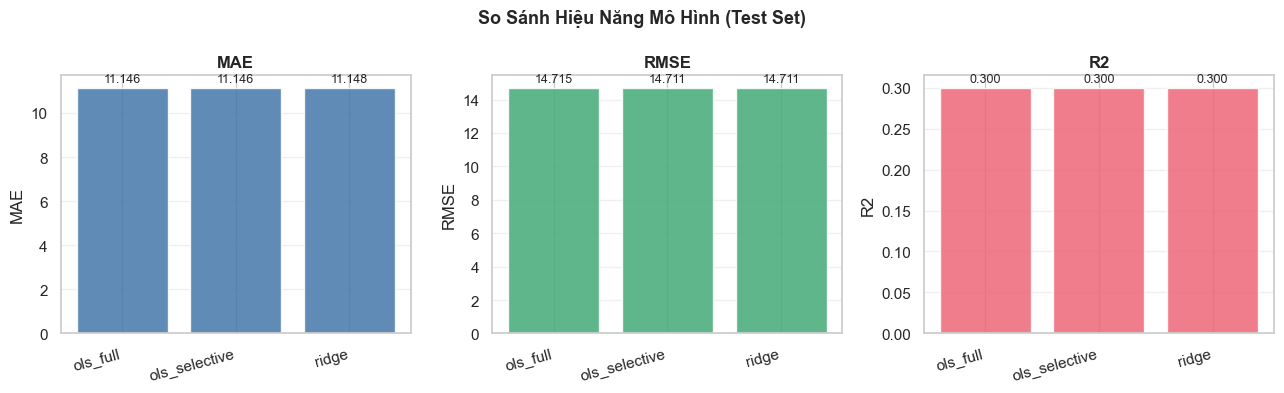

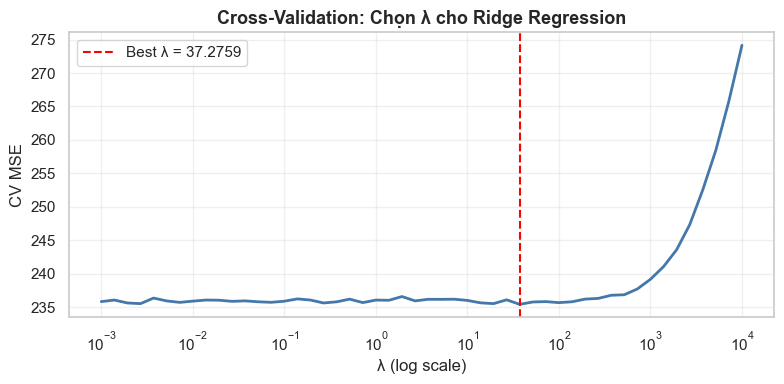

In [13]:
fig_comp = plot_model_comparison(results)
plt.show()

fig_cv = plot_cv_lambda(models['ridge']['cv_results'], models['ridge']['lambda'])
plt.show()

### Nhận xét

- Ridge và OLS cơ bản cho kết quả rất gần nhau — đa cộng tuyến không còn là vấn đề nghiêm trọng sau khi đã tinh lọc đặc trưng ở bước EDA.
- OLS chọn biến loại bớt biến nhưng vẫn giữ $R^2$ gần tương đương, xác nhận rằng một số biến đóng góp rất ít.
- Sai số dự đoán (MAE) ở mức vừa phải, phù hợp cho bài toán sàng lọc huyết áp ban đầu.

---
## VII. Phân tích phần dư & Feature Importance

Mô hình tốt nhất: ols_selective



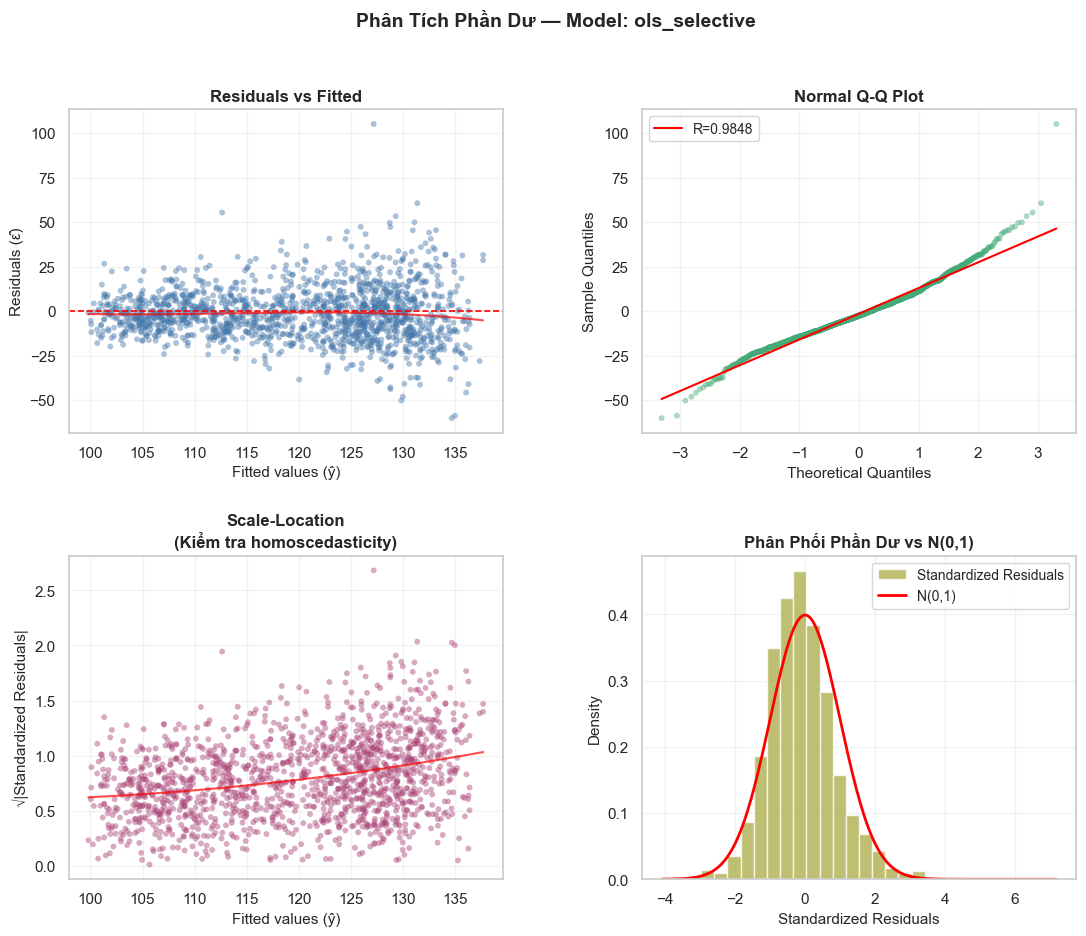

In [14]:
best_key = results.loc[results['R2'].idxmax(), 'Model']
print(f"Mô hình tốt nhất: {best_key}\n")

fig_res = run_residual_analysis(best_key, models, X_test, y_test)
plt.show()

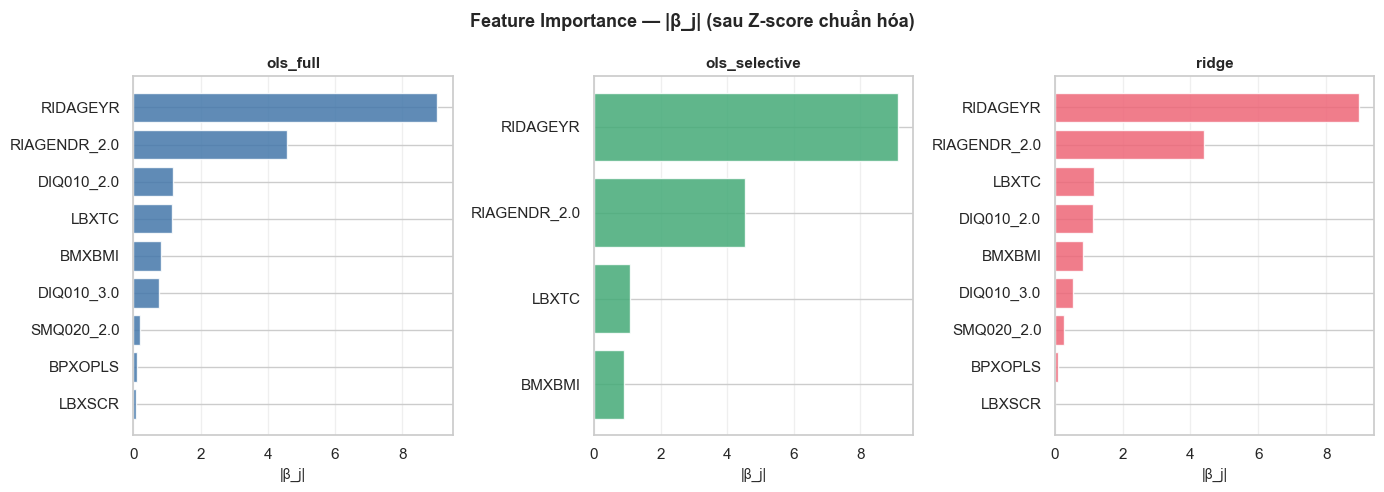

In [15]:
fig_imp = plot_feature_importance(models)
plt.show()

### Biện luận

- `RIDAGEYR` (tuổi) là yếu tố ảnh hưởng lớn nhất — sự lão hóa mạch máu trực tiếp thúc đẩy tăng huyết áp tâm thu.
- `BMXBMI` đứng thứ hai — béo phì là yếu tố lối sống có thể kiểm soát, củng cố khuyến cáo lâm sàng rằng giảm cân là phương pháp không dùng thuốc hiệu quả nhất.
- `BPXOPLS` (nhịp tim) và `LBXSCR` (creatinine) phản ánh hoạt động giao cảm và chức năng thận.

---
## VIII. Kỹ thuật nâng cao — Kernel Ridge Regression (Bonus)

Kernel Ridge mở rộng OLS sang không gian đặc trưng phi tuyến qua kernel trick với RBF kernel:

$$\hat{y}(x^*) = k(x^*, X_{train})^T \alpha, \quad \alpha = (K + \lambda I)^{-1} y$$

Siêu tham số $(\lambda, \ell)$ được chọn bằng grid search 5-fold CV trên subsample **800 mẫu** (do độ phức tạp $O(n^3)$).

In [16]:
from advanced_methods import (
    tune_kernel_ridge, compare_kernel_vs_ols,
    kernel_ridge_fit, kernel_ridge_predict,
    plot_cv_heatmap
)
%matplotlib inline

X_train_nb = X_train[:, 1:]
X_test_nb = X_test[:, 1:]

rng = np.random.default_rng(42)
sub_idx = rng.choice(len(y_train), min(800, len(y_train)), replace=False)
X_cv, y_cv = X_train_nb[sub_idx], y_train[sub_idx]

print(f"Grid search CV trên {len(sub_idx)} mẫu...")
best_lam, best_l, cv_res = tune_kernel_ridge(
    X_cv, y_cv,
    lam_grid=np.logspace(-1, 3, 8),
    l_grid=np.logspace(-1, 1, 5),
    k=5, seed=42
)
print(f"Best λ = {best_lam:.4f}, Best ℓ = {best_l:.4f}\n")

results_kr = compare_kernel_vs_ols(
    X_train_nb, y_train, X_test_nb, y_test,
    lam=best_lam, l=best_l
)
print("So sánh Kernel Ridge vs OLS trên tập test:")
display(results_kr)

Grid search CV trên 800 mẫu...
Best λ = 0.1000, Best ℓ = 10.0000

So sánh Kernel Ridge vs OLS trên tập test:


,Model,MAE,RMSE,R2,R2_adj
0,OLS,11.1457,14.7153,0.2996,0.2954
1,Kernel Ridge,11.0912,14.8892,0.2829,0.2786


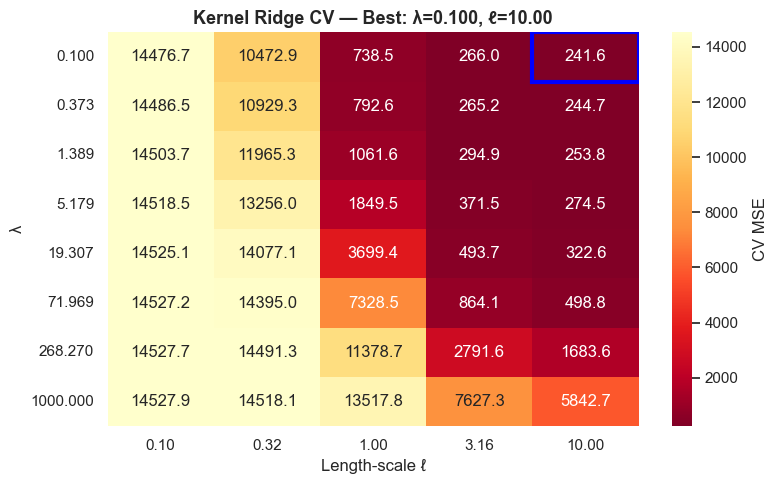

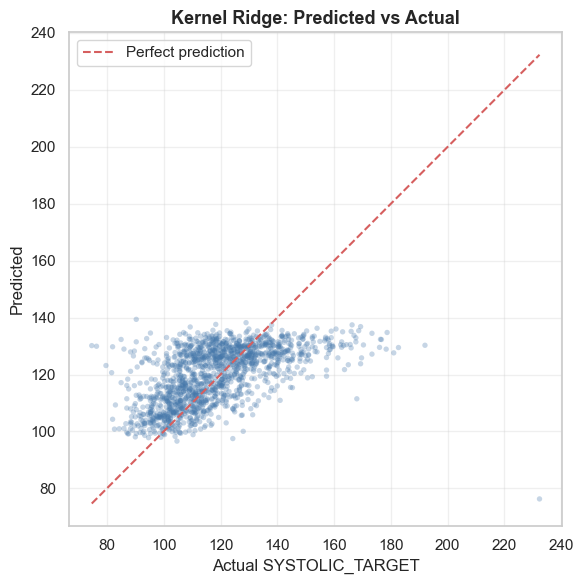

In [17]:
fig_hm = plot_cv_heatmap(cv_res, best_lam, best_l)
plt.show()

kr_res = kernel_ridge_fit(X_train_nb, y_train, lam=best_lam, l=best_l)
y_pred = kernel_ridge_predict(X_train_nb, X_test_nb, kr_res['alpha'], l=best_l)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test, y_pred, alpha=0.3, s=15, color='#4477AA', edgecolors='none')
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
ax.set_xlabel('Actual SYSTOLIC_TARGET', fontsize=12)
ax.set_ylabel('Predicted', fontsize=12)
ax.set_title('Kernel Ridge: Predicted vs Actual', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Nhận xét

Kernel Ridge với RBF kernel có khả năng bắt được các mối quan hệ phi tuyến mà OLS tuyến tính không thể. Tuy nhiên, độ phức tạp $O(n^3)$ hạn chế khả năng mở rộng trên tập dữ liệu lớn — do đó sử dụng subsample 800 mẫu cho quá trình tuning.

---
## IX. Kết luận và Diễn giải Y sinh học

Nghiên cứu đã xây dựng thành công pipeline hoàn chỉnh từ dữ liệu thô NHANES đến các mô hình dự đoán huyết áp tâm thu cơ sở. Dưới đây là những phát hiện khoa học quan trọng nhất rút ra từ mô hình tối ưu OLS Chọn biến:

### 1. Diễn giải các hệ số mô hình (Huyết áp tâm thu cơ sở: 121.71 mmHg)

Mô hình tối ưu rút gọn chỉ giữ lại 4 biến ý nghĩa nhất nhưng vẫn đạt hiệu năng tương đương mô hình đầy đủ, với các hệ số cụ thể sau:

*   **Tuổi tác (`RIDAGEYR`): +9.20 mmHg** mỗi độ lệch chuẩn tăng thêm. Đây là yếu tố tác động mạnh nhất, phản ánh quá trình lão hóa tự nhiên của hệ tim mạch khi thành mạch xơ cứng và giảm tính đàn hồi theo thời gian.
*   **Chỉ số khối cơ thể (`BMXBMI`): +0.93 mmHg** mỗi độ lệch chuẩn tăng thêm. Trọng lượng cơ thể lớn buộc tim co bóp mạnh hơn và tạo ra lực cản ngoại vi cao hơn.
*   **Tổng Cholesterol (`LBXTC`): +0.93 mmHg** mỗi độ lệch chuẩn tăng thêm. Lipid máu cao thúc đẩy hình thành các mảng xơ vữa, làm hẹp lòng mạch.
*   **Giới tính Nữ (`RIAGENDR`): -4.49 mmHg** so với nam giới. Phản ánh vai trò bảo vệ tim mạch tự nhiên của các hormone sinh dục nữ như estrogen.

### 2. Ý nghĩa thực tiễn đối với mục tiêu sức khỏe cộng đồng

*   **Yếu tố không thể thay đổi (Tuổi, Giới tính):** Đóng vai trò định hình rủi ro nền tảng. Điều này nhấn mạnh tầm quan trọng của việc chủ động tầm soát huyết áp ở nhóm đối tượng lớn tuổi và nam giới.
*   **Yếu tố có thể can thiệp (BMI, Cholesterol):** Dù có hệ số tác động nhỏ hơn tuổi tác, đây là hai yếu tố có thể chủ động điều chỉnh được thông qua chế độ ăn uống, tập luyện và lối sống lành mạnh để kiểm soát huyết áp hiệu quả mà không cần can thiệp y tế sâu.

### 3. Giới hạn mô hình và hướng đi tiếp theo

Hệ số xác định $R^2 \approx 0.30$ phản ánh đặc tính tự nhiên của dữ liệu y sinh thực tế, khi huyết áp chịu ảnh hưởng bởi rất nhiều yếu tố phức tạp chưa được đo lường (như di truyền học, căng thẳng tâm lý, hay chế độ dinh dưỡng chi tiết). Mặc dù vậy, mô hình vẫn cung cấp một công cụ sàng lọc ban đầu nhanh chóng, khả thi và có ý nghĩa thống kê cao.

---
## X. Unit Tests

Dưới đây là phần Unit Tests được tích hợp trực tiếp vào notebook nhằm kiểm định tính chính xác của các lớp và hàm trong pipeline tiền xử lý dữ liệu (`EDA`, `DataPipeline`).

In [18]:
import unittest
import numpy as np
import pandas as pd
from data_pipeline import EDA, DataPipeline

class TestPart2(unittest.TestCase):

    def setUp(self):
        # Dữ liệu kiểm định mẫu chứa các biến liên tục và phân loại có missing values
        self.df_dummy = pd.DataFrame({
            'RIDAGEYR': [20.0, 40.0, 60.0, 80.0, np.nan],
            'BMXBMI':   [18.0, 22.0, np.nan, 30.0, 26.0],
            'BPXOPLS':  [60.0, 70.0, 80.0, np.nan, 90.0],
            'LBXTC':    [150.0, np.nan, 200.0, 220.0, 180.0],
            'LBXSCR':   [0.6, 0.8, 1.0, 1.2, 0.9],  # Không có NaN
            'RIAGENDR': [1.0, 2.0, 1.0, 2.0, 1.0],
            'SMQ020':   [1.0, 2.0, 1.0, 2.0, 7.0],  # 7.0 là invalid
            'DIQ010':   [1.0, 2.0, 3.0, 1.0, 2.0],
            'SYSTOLIC_TARGET': [110.0, 120.0, 130.0, 140.0, 125.0]
        })

    def test_eda_mean_imple_no_nan(self):
        """Test 1 cho EDA.meanImple: Biến không có NaN"""
        eda = EDA(self.df_dummy[['LBXSCR']].copy())
        means = eda.meanImple()
        # Mean của [0.6, 0.8, 1.0, 1.2, 0.9] là 0.9
        self.assertAlmostEqual(means[0], 0.9, places=5)

    def test_eda_mean_imple_with_nan(self):
        """Test 2 cho EDA.meanImple: Biến có chứa NaN"""
        eda = EDA(self.df_dummy[['RIDAGEYR']].copy())
        means = eda.meanImple()
        # Mean của [20.0, 40.0, 60.0, 80.0] (bỏ qua NaN) là 50.0
        self.assertAlmostEqual(means[0], 50.0, places=5)

    def test_eda_median_quantiles_odd(self):
        """Test 1 cho EDA.medianAndQuantilesImple: Số lượng phần tử lẻ"""
        df_odd = pd.DataFrame({'val': [10.0, 20.0, 30.0, 40.0, 50.0]})
        eda = EDA(df_odd)
        quantiles = eda.medianAndQuantilesImple()
        q1, median_val, q3 = quantiles[0]
        self.assertAlmostEqual(median_val, 30.0, places=5)
        self.assertAlmostEqual(q1, 20.0, places=5)
        self.assertAlmostEqual(q3, 40.0, places=5)

    def test_eda_median_quantiles_even(self):
        """Test 2 cho EDA.medianAndQuantilesImple: Số lượng phần tử chẵn"""
        df_even = pd.DataFrame({'val': [10.0, 20.0, 30.0, 40.0]})
        eda = EDA(df_even)
        quantiles = eda.medianAndQuantilesImple()
        q1, median_val, q3 = quantiles[0]
        # Median của [10, 20, 30, 40] là 25.0
        self.assertAlmostEqual(median_val, 25.0, places=5)

    def test_eda_std_imple_no_nan(self):
        """Test 1 cho EDA.stdImple: Độ lệch chuẩn không có NaN"""
        df_std = pd.DataFrame({'val': [1.0, 2.0, 3.0]})
        eda = EDA(df_std)
        stds = eda.stdImple()
        # std của [1, 2, 3] với ddof=1 là 1.0
        self.assertAlmostEqual(stds[0], 1.0, places=5)

    def test_eda_std_imple_with_nan(self):
        """Test 2 cho EDA.stdImple: Có chứa NaN"""
        eda = EDA(self.df_dummy[['BMXBMI']].copy())
        stds = eda.stdImple()
        # Cột BMXBMI có [18.0, 22.0, 30.0, 26.0] (bỏ qua NaN)
        # Mean = 24.0, std (ddof=1) = sqrt(((18-24)^2 + (22-24)^2 + (30-24)^2 + (26-24)^2)/3) = sqrt(80/3)
        self.assertAlmostEqual(stds[0], np.sqrt(80.0/3.0), places=5)

    def test_pipeline_standardization(self):
        """Test 1 cho DataPipeline: Kiểm tra tính đúng đắn của chuẩn hóa Z-score"""
        CONTINUOUS  = ['RIDAGEYR', 'BMXBMI', 'BPXOPLS', 'LBXTC', 'LBXSCR']
        CATEGORICAL = ['RIAGENDR', 'SMQ020', 'DIQ010']
        INVALID     = {'SMQ020': [7.0, 9.0]}

        pipe = DataPipeline(CONTINUOUS, CATEGORICAL, target_col='SYSTOLIC_TARGET', invalid_cat_values=INVALID, k=2)
        df_large = pd.concat([self.df_dummy, self.df_dummy], ignore_index=True)

        pipe.fit(df_large)
        X_trans, feat_names = pipe.transform(df_large)

        # Trích xuất cột LBXSCR (index 5) - cột này không có NaN nên không bị ảnh hưởng bởi imputation
        lbxscr_trans = X_trans[:, 5]
        # Sau khi chuẩn hóa Z-score, mean trên tập Train phải bằng 0.0
        self.assertAlmostEqual(float(np.mean(lbxscr_trans)), 0.0, places=5)
        self.assertAlmostEqual(float(np.std(lbxscr_trans, ddof=1)), 1.0, places=5)

    def test_pipeline_no_nan_left(self):
        """Test 2 cho DataPipeline: Đảm bảo không còn bất kỳ giá trị NaN nào sau khi transform"""
        CONTINUOUS  = ['RIDAGEYR', 'BMXBMI', 'BPXOPLS', 'LBXTC', 'LBXSCR']
        CATEGORICAL = ['RIAGENDR', 'SMQ020', 'DIQ010']
        INVALID     = {'SMQ020': [7.0, 9.0]}

        pipe = DataPipeline(CONTINUOUS, CATEGORICAL, target_col='SYSTOLIC_TARGET', invalid_cat_values=INVALID, k=2)
        df_large = pd.concat([self.df_dummy, self.df_dummy], ignore_index=True)

        pipe.fit(df_large)
        X_trans, _ = pipe.transform(df_large)

        # Kiểm tra không có giá trị NaN nào trong mảng NumPy kết quả
        self.assertFalse(np.isnan(X_trans).any())

# Chạy unit tests trong notebook
suite = unittest.TestLoader().loadTestsFromTestCase(TestPart2)
unittest.TextTestRunner(verbosity=2).run(suite)


test_eda_mean_imple_no_nan (__main__.TestPart2.test_eda_mean_imple_no_nan)
Test 1 cho EDA.meanImple: Biến không có NaN ... ok
test_eda_mean_imple_with_nan (__main__.TestPart2.test_eda_mean_imple_with_nan)
Test 2 cho EDA.meanImple: Biến có chứa NaN ... ok
test_eda_median_quantiles_even (__main__.TestPart2.test_eda_median_quantiles_even)
Test 2 cho EDA.medianAndQuantilesImple: Số lượng phần tử chẵn ... ok
test_eda_median_quantiles_odd (__main__.TestPart2.test_eda_median_quantiles_odd)
Test 1 cho EDA.medianAndQuantilesImple: Số lượng phần tử lẻ ... ok
test_eda_std_imple_no_nan (__main__.TestPart2.test_eda_std_imple_no_nan)
Test 1 cho EDA.stdImple: Độ lệch chuẩn không có NaN ... ok
test_eda_std_imple_with_nan (__main__.TestPart2.test_eda_std_imple_with_nan)
Test 2 cho EDA.stdImple: Có chứa NaN ... ok
test_pipeline_no_nan_left (__main__.TestPart2.test_pipeline_no_nan_left)
Test 2 cho DataPipeline: Đảm bảo không còn bất kỳ giá trị NaN nào sau khi transform ... ok
test_pipeline_standardizatio

Donor pool sau lọc outlier sinh học/IQR: còn 2 bản ghi sạch.
Donor pool sau lọc outlier sinh học/IQR: còn 2 bản ghi sạch.


<unittest.runner.TextTestResult run=8 errors=0 failures=0>